In [1]:
import sys
sys.path.append('../../src')  # repo-relative: notebooks/pipeline/../../src
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import *

train_df = pd.read_csv(os.path.join(PROC_DIR, 'train_step07.csv'))
test_df = pd.read_csv(os.path.join(PROC_DIR, 'test_step07.csv'))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

print(f"\nColumns in train: {len(train_df.columns)}")
print(f"Columns in test: {len(test_df.columns)}")


Train shape: (77299, 30)
Test shape: (41778, 29)

Columns in train: 30
Columns in test: 29


temp_squared: min=0.00, max=2328.20, mean=321.56


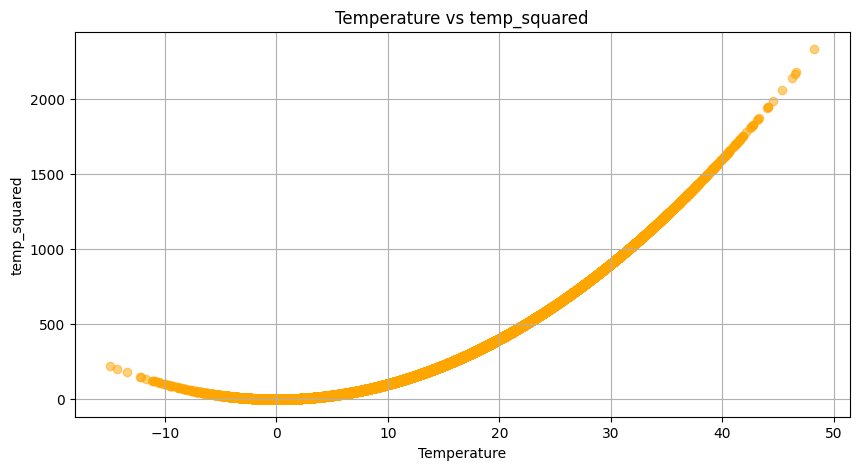


Correlation of Temperature with demand: 0.0031
Correlation of temp_squared with demand: 0.0032


In [2]:
# temp_squared to capture the inverted-U shape from the bivariate EDA (demand
# lowest at temperature extremes, highest in the mid-range). Note the linear
# Pearson correlation below comes out near zero for both Temperature and
# temp_squared — expected for a symmetric non-linear relationship, since a
# straight-line correlation can't see a U-shape. The tree models use it via
# splits, not via linear correlation, so this near-zero number isn't a red
# flag for dropping the feature the way it would be for a linear model.
train_df['temp_squared'] = np.square(train_df['Temperature'])
test_df['temp_squared'] = np.square(test_df['Temperature'])

print(f"temp_squared: min={train_df['temp_squared'].min():.2f}, max={train_df['temp_squared'].max():.2f}, mean={train_df['temp_squared'].mean():.2f}")

plt.figure(figsize=(10, 5))
plt.scatter(train_df['Temperature'], train_df['temp_squared'], alpha=0.5, color='orange')
plt.title('Temperature vs temp_squared')
plt.xlabel('Temperature')
plt.ylabel('temp_squared')
plt.grid(True)
os.makedirs(UNIVARIATE_PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(UNIVARIATE_PLOTS_DIR, 'temp_squared_check.png'))
plt.show()

corr_temp = train_df[['Temperature', 'demand']].corr().iloc[0, 1]
corr_temp_sq = train_df[['temp_squared', 'demand']].corr().iloc[0, 1]

print(f"\nCorrelation of Temperature with demand: {corr_temp:.4f}")
print(f"Correlation of temp_squared with demand: {corr_temp_sq:.4f}")


In [3]:
present_count = 0
print("Feature Verification:")
for feature in FINAL_FEATURES:
    if feature in train_df.columns:
        print(f"[PASS] {feature}")
        present_count += 1
    else:
        print(f"[FAIL/WARNING] {feature} is missing!")

print(f"\nTotal features present: {present_count} / {len(FINAL_FEATURES)}")


Feature Verification:
[PASS] geohash_target_enc
[PASS] latitude
[PASS] longitude
[PASS] geohash_prefix_enc
[PASS] hour
[PASS] hour_sin
[PASS] hour_cos
[PASS] is_peak_hour
[PASS] is_business_hour
[PASS] is_night
[PASS] hour_squared
[PASS] road_type_ord
[PASS] NumberofLanes
[PASS] road_capacity
[PASS] weather_severity
[PASS] Temperature
[PASS] temp_squared
[PASS] road_combo
[PASS] hour_x_roadtype
[PASS] geo_hour_sin
[PASS] road_x_weather
[PASS] geo_x_roadtype
[PASS] geo_x_weather
[PASS] lanes_x_weather
[PASS] geo_x_peak
[PASS] temp_x_weather

Total features present: 26 / 26


In [4]:
summary_data = []

for feature in FINAL_FEATURES:
    col = train_df[feature]
    summary_data.append({
        'Feature': feature,
        'Dtype': col.dtype,
        'Min': col.min() if pd.api.types.is_numeric_dtype(col) else None,
        'Max': col.max() if pd.api.types.is_numeric_dtype(col) else None,
        'Mean': col.mean() if pd.api.types.is_numeric_dtype(col) else None,
        'Null_Count': col.isnull().sum()
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

total_nulls = summary_df['Null_Count'].sum()
print(f"\nTotal nulls across all {len(FINAL_FEATURES)} features: {total_nulls}")


,Feature,Dtype,Min,Max,Mean,Null_Count
0,geohash_target_enc,float64,3.596047e-04,0.963684,0.093979,0
1,latitude,float64,-5.484924e+00,-5.237732,-5.348365,0
2,longitude,float64,9.058777e+01,90.972290,90.764108,0
3,geohash_prefix_enc,float64,2.619374e-02,0.139909,0.093942,0
4,hour,int64,0.000000e+00,23.000000,9.101347,0
5,hour_sin,float64,-1.000000e+00,1.000000,0.182811,0
6,hour_cos,float64,-1.000000e+00,1.000000,0.065783,0
7,is_peak_hour,int64,0.000000e+00,1.000000,0.209421,0
8,is_business_hour,int64,0.000000e+00,1.000000,0.393446,0
9,is_night,int64,0.000000e+00,1.000000,0.487717,0



Total nulls across all 26 features: 0


In [5]:
train_cols_to_keep = FINAL_FEATURES + ['demand']
train_df = train_df[train_cols_to_keep]

print("Final Train Columns:")
print(train_df.columns.tolist())
print(f"\nTrain shape after dropping: {train_df.shape}")

test_cols_to_keep = FINAL_FEATURES
test_df = test_df[test_cols_to_keep]

print("\nFinal Test Columns:")
print(test_df.columns.tolist())
print(f"\nTest shape after dropping: {test_df.shape}")


Final Train Columns:
['geohash_target_enc', 'latitude', 'longitude', 'geohash_prefix_enc', 'hour', 'hour_sin', 'hour_cos', 'is_peak_hour', 'is_business_hour', 'is_night', 'hour_squared', 'road_type_ord', 'NumberofLanes', 'road_capacity', 'weather_severity', 'Temperature', 'temp_squared', 'road_combo', 'hour_x_roadtype', 'geo_hour_sin', 'road_x_weather', 'geo_x_roadtype', 'geo_x_weather', 'lanes_x_weather', 'geo_x_peak', 'temp_x_weather', 'demand']

Train shape after dropping: (77299, 27)

Final Test Columns:
['geohash_target_enc', 'latitude', 'longitude', 'geohash_prefix_enc', 'hour', 'hour_sin', 'hour_cos', 'is_peak_hour', 'is_business_hour', 'is_night', 'hour_squared', 'road_type_ord', 'NumberofLanes', 'road_capacity', 'weather_severity', 'Temperature', 'temp_squared', 'road_combo', 'hour_x_roadtype', 'geo_hour_sin', 'road_x_weather', 'geo_x_roadtype', 'geo_x_weather', 'lanes_x_weather', 'geo_x_peak', 'temp_x_weather']

Test shape after dropping: (41778, 26)


In [6]:
train_df.to_csv(os.path.join(PROC_DIR, 'train_step08.csv'), index=False)
test_df.to_csv(os.path.join(PROC_DIR, 'test_step08.csv'), index=False)

print(f"Saved Train shape: {train_df.shape}")
print(f"Saved Test shape: {test_df.shape}")
print(f"Saved to: {os.path.join(PROC_DIR, 'train_step08.csv')}")
print(f"Saved to: {os.path.join(PROC_DIR, 'test_step08.csv')}")


Saved Train shape: (77299, 27)
Saved Test shape: (41778, 26)
Saved to: C:\TRAFFIC-DEMAND-FINAL\data\processed\train_step08.csv
Saved to: C:\TRAFFIC-DEMAND-FINAL\data\processed\test_step08.csv
